In [53]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [54]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)

X = mnist.data      
y = mnist.target.astype(int)   

# Split manually — first 60000 train, last 10000 test
X_train, X_test = X[:60000], X[60000:]
Y_train, Y_test = y[:60000], y[60000:]

print(X_train.shape)   
print(Y_train.shape)   

(60000, 784)
(60000,)


In [55]:
X_train = X_train / 255
X_test= X_test/255
X_train = X_train.T   
X_test  = X_test.T 
Y_train = tf.one_hot(Y_train, depth=10)  
Y_test = tf.one_hot(Y_test, depth=10)  
Y_train = tf.transpose(Y_train)
Y_test  = tf.transpose(Y_test) 

In [56]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(784, 60000)
(10, 60000)
(784, 10000)
(10, 10000)


In [57]:
def initialize_parameters():
    initializer=tf.keras.initializers.HeNormal(seed=1)
    W1=tf.Variable(initializer(shape=(256,784)))
    b1=tf.Variable(tf.zeros(shape=(256,1)))
    W2=tf.Variable(initializer(shape=(128,256)))
    b2=tf.Variable((tf.zeros(shape=(128,1))))
    W3=tf.Variable(initializer(shape=(10,128)))
    b3=tf.Variable((tf.zeros(shape=(10,1))))
    params= {"W1": W1, "b1": b1,
            "W2": W2, "b2": b2,
            "W3": W3, "b3": b3} 
    return params 

In [58]:
params=initialize_parameters()
for i,j in params.items():
    print(i,j.shape)

W1 (256, 784)
b1 (256, 1)
W2 (128, 256)
b2 (128, 1)
W3 (10, 128)
b3 (10, 1)


In [59]:
def forward_propagation(X,params) :
    W1=params["W1"]
    W2=params["W2"]
    W3=params["W3"]
    b1=params["b1"]
    b2=params["b2"]
    b3=params["b3"]
    Z1=tf.matmul(W1,X)+b1
    A1=tf.keras.activations.relu(Z1)
    Z2=tf.matmul(W2,A1)+b2
    A2=tf.keras.activations.relu(Z2)
    Z3=tf.matmul(W3,A2)+b3
    return Z3

In [63]:
def compute_total_loss(Z3,Y,params,lambd=0.1):
    cross_entropy_loss=tf.reduce_sum(
    tf.keras.losses.categorical_crossentropy(
        tf.transpose(Y),
        tf.transpose(Z3),
        from_logits=True
    ))
    m=Y.shape[1]
    W1=params["W1"]
    W2=params["W2"]
    W3=params["W3"]
    l2_penalty= (lambd/(2*m))*(
        tf.reduce_sum(tf.square(W1))+
        tf.reduce_sum(tf.square(W2))+
        tf.reduce_sum(tf.square(W3))
    )
    total_loss=  cross_entropy_loss + l2_penalty
    return total_loss

In [64]:
def model(X_train, Y_train, params, learning_rate=0.001, epochs=100, batch_size=256,lambd=0.1):
    optimizer = tf.keras.optimizers.Adam(learning_rate)
    m = X_train.shape[1]
    costs = []

    for epoch in range(epochs):          
        epoch_cost = 0                   
        batches = []
        for i in range(0, m, batch_size):
            X_batch = X_train[:, i:i+batch_size]
            Y_batch = Y_train[:, i:i+batch_size]
            batches.append((X_batch, Y_batch))
        
        for (X_batch, Y_batch) in batches:   
            with tf.GradientTape() as tape:   
                Z3   = forward_propagation(X_batch, params)
                loss = compute_total_loss(Z3, Y_batch,params,lambd)
            
            trainable_vars = list(params.values())
            grads = tape.gradient(loss, trainable_vars)
            optimizer.apply_gradients(zip(grads, trainable_vars))
            
            epoch_cost += loss / m       
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Cost: {epoch_cost:.4f}")
            costs.append(epoch_cost)
    
    return params, costs

In [66]:
params = initialize_parameters()
params, costs = model(X_train, Y_train, params, 
                      learning_rate=0.001, 
                      epochs=70, 
                      batch_size=256,lambd=0.1)

Epoch 0, Cost: 0.6919
Epoch 10, Cost: 0.2195
Epoch 20, Cost: 0.1605
Epoch 30, Cost: 0.1242
Epoch 40, Cost: 0.0992
Epoch 50, Cost: 0.0832
Epoch 60, Cost: 0.0772


In [67]:
def evaluate(X,Y,params):
    Z3=forward_propagation(X,params)
    predictions=tf.argmax(Z3,axis=0)
    true_labels=tf.argmax(Y,axis=0)
    accuracy=tf.reduce_mean(tf.cast(tf.equal(predictions,true_labels),tf.float32))
    return accuracy.numpy()
train_acc = evaluate(X_train, Y_train, params)
test_acc  = evaluate(X_test,  Y_test,  params)

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")

Train Accuracy: 95.48%
Test Accuracy:  88.29%


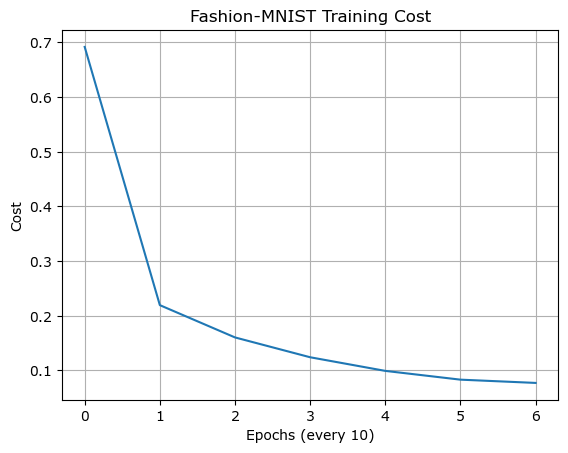

In [68]:
plt.plot(costs)
plt.xlabel("Epochs (every 10)")
plt.ylabel("Cost")
plt.title("Fashion-MNIST Training Cost")
plt.grid(True)
plt.show()

In [69]:
def predict_from_dataset(index, X_test, Y_test, params):
    
    X_sample = X_test[:, index:index+1]
    true_label = tf.argmax(Y_test[:, index])
    
    Z3 = forward_propagation(X_sample, params)
    prediction = tf.argmax(Z3, axis=0).numpy()[0]
    confidence = tf.nn.softmax(Z3, axis=0).numpy()[prediction][0] * 100
    
    # Fixed line — no .numpy() needed
    img = X_test[:, index].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {class_names[true_label]} | Pred: {class_names[prediction]} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()
    
    print(f"True Label:  {class_names[true_label]}")
    print(f"Predicted:   {class_names[prediction]}")
    print(f"Confidence:  {confidence:.1f}%")
    print(f"Correct:     {'✅' if prediction == true_label.numpy() else '❌'}")

In [70]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

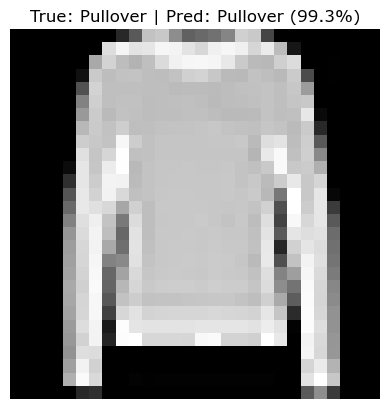

True Label:  Pullover
Predicted:   Pullover
Confidence:  99.3%
Correct:     ✅


In [74]:
predict_from_dataset(99, X_test, Y_test, params)